In [1]:
# Cell 1 — Imports
from dotenv import load_dotenv
import os
load_dotenv(r'C:\Users\Gurveer\ds-portfolio\.env')
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

import requests
import json
import base64
import numpy as np
import pandas as pd
import plotly.express as px
from PIL import Image
from io import BytesIO
from openai import OpenAI
import warnings
warnings.filterwarnings('ignore')

client = OpenAI()
print("All imports successful")

# Test Ollama connection
try:
    resp = requests.get("http://localhost:11434/api/tags")
    models = [m['name'] for m in resp.json()['models']]
    print(f"Ollama running — models: {models}")
except:
    print("Ollama not running — start it first")

All imports successful
Ollama not running — start it first


In [4]:
# Cell 2 — Use local image file
import urllib.request
from PIL import Image
data_dir = r'C:\Users\Gurveer\ds-portfolio\project-27-recipe-maker\data'
img_path = f'{data_dir}\\sample_food.jpg'
img = Image.open(img_path)
print(f"Image size: {img.size}")
print(f"Image mode: {img.mode}")

# Download a food image to local data folder
data_dir = r'C:\Users\Gurveer\ds-portfolio\project-27-recipe-maker\data'
os.makedirs(data_dir, exist_ok=True)

# Download sample food image
img_url = "https://images.unsplash.com/photo-1512621776951-a57141f2eefd?w=640"
img_path = f'{data_dir}\\sample_food.jpg'

headers = {'User-Agent': 'Mozilla/5.0'}
req = urllib.request.Request(img_url, headers=headers)
with urllib.request.urlopen(req) as r:
    with open(img_path, 'wb') as f:
        f.write(r.read())
print(f"Image saved to: {img_path}")

def encode_image_from_file(image_path):
    """Encode local image as base64"""
    img = Image.open(image_path).convert('RGB')
    img.thumbnail((512, 512))
    buffer = BytesIO()
    img.save(buffer, format='JPEG')
    return base64.b64encode(buffer.getvalue()).decode('utf-8')

def detect_food_gemma4(image_path):
    """Use Gemma 4 vision to detect food items from local file"""
    print("Encoding image...")
    img_b64 = encode_image_from_file(image_path)
    
    prompt = """Look at this image carefully.
Identify ALL food items, ingredients, and produce you can see.
Return your response as JSON with this exact format:
{
  "detected_items": ["item1", "item2", "item3"],
  "confidence": "high/medium/low",
  "scene_description": "brief description of what you see",
  "cuisine_hints": ["possible cuisine type based on ingredients"]
}
Only return the JSON, nothing else."""

    print("Running Gemma 4 vision inference (30-60 seconds)...")
    response = requests.post(
        "http://localhost:11434/api/generate",
        json={
            "model":  "gemma4:latest",
            "prompt": prompt,
            "images": [img_b64],
            "stream": False,
            "options": {"temperature": 0.1}
        },
        timeout=300
    )
    
    raw = response.json()['response'].strip()
    raw = raw.replace("```json","").replace("```","").strip()
    
    try:
        return json.loads(raw)
    except:
        return {"detected_items": [raw],
                "confidence": "medium",
                "scene_description": raw,
                "cuisine_hints": ["unknown"]}

print("\n=== GEMMA 4 FOOD DETECTION ===")
result = detect_food_gemma4(img_path)
print(f"\nDetected items:    {result.get('detected_items', [])}")
print(f"Confidence:        {result.get('confidence', 'N/A')}")
print(f"Scene description: {result.get('scene_description', 'N/A')}")
print(f"Cuisine hints:     {result.get('cuisine_hints', [])}")

Image size: (640, 427)
Image mode: RGB
Image saved to: C:\Users\Gurveer\ds-portfolio\project-27-recipe-maker\data\sample_food.jpg

=== GEMMA 4 FOOD DETECTION ===
Encoding image...
Running Gemma 4 vision inference (30-60 seconds)...

Detected items:    ['lettuce', 'avocado', 'cherry tomatoes', 'yellow bell pepper', 'beetroot', 'purple cabbage', 'chickpeas', 'sweet potato', 'microgreens', 'dressing']
Confidence:        high
Scene description: A colorful and healthy composed salad bowl featuring various fresh vegetables, legumes, and starches, served on a wooden table.
Cuisine hints:     ['Mediterranean', 'Californian', 'Vegan/Plant-based']


In [5]:
# Cell 3 — Recipe Generator from Detected Ingredients
def generate_recipe(detected_items, cuisine_hints, dietary_pref="none"):
    """Generate a complete recipe from detected ingredients using GPT-4o-mini"""
    
    ingredients_str = ", ".join(detected_items)
    cuisine_str     = ", ".join(cuisine_hints)
    
    prompt = f"""You are a professional chef and nutritionist.

Detected ingredients: {ingredients_str}
Cuisine style: {cuisine_str}
Dietary preference: {dietary_pref}

Create a complete, detailed recipe using these ingredients.

Return ONLY valid JSON:
{{
  "recipe_name": "Name of the dish",
  "cuisine": "Cuisine type",
  "prep_time_min": 15,
  "cook_time_min": 20,
  "servings": 2,
  "difficulty": "Easy/Medium/Hard",
  "ingredients": [
    {{"item": "ingredient name", "amount": "quantity", "unit": "unit"}}
  ],
  "instructions": [
    {{"step": 1, "instruction": "detailed step"}}
  ],
  "nutrition_per_serving": {{
    "calories": 450,
    "protein_g": 15,
    "carbs_g": 45,
    "fat_g": 20,
    "fiber_g": 8
  }},
  "chef_tips": ["tip1", "tip2"],
  "wine_pairing": "optional wine suggestion"
}}"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=1500,
        temperature=0.7
    )
    
    raw = response.choices[0].message.content.strip()
    raw = raw.replace("```json","").replace("```","").strip()
    return json.loads(raw)

print("Generating recipe from detected ingredients...")
recipe = generate_recipe(
    result['detected_items'],
    result['cuisine_hints'],
    dietary_pref="vegetarian"
)

print(f"\n{'='*55}")
print(f"  {recipe['recipe_name'].upper()}")
print(f"{'='*55}")
print(f"  Cuisine:     {recipe['cuisine']}")
print(f"  Prep time:   {recipe['prep_time_min']} min")
print(f"  Cook time:   {recipe['cook_time_min']} min")
print(f"  Servings:    {recipe['servings']}")
print(f"  Difficulty:  {recipe['difficulty']}")
print(f"\n  Ingredients:")
for ing in recipe['ingredients']:
    print(f"    • {ing['amount']} {ing['unit']} {ing['item']}")
print(f"\n  Instructions:")
for step in recipe['instructions']:
    print(f"    {step['step']}. {step['instruction']}")
print(f"\n  Nutrition per serving:")
n = recipe['nutrition_per_serving']
print(f"    Calories: {n['calories']} | Protein: {n['protein_g']}g | "
      f"Carbs: {n['carbs_g']}g | Fat: {n['fat_g']}g | Fiber: {n['fiber_g']}g")
print(f"\n  Chef tips:")
for tip in recipe['chef_tips']:
    print(f"    💡 {tip}")

Generating recipe from detected ingredients...

  MEDITERRANEAN CHICKPEA SALAD WITH ROASTED SWEET POTATO
  Cuisine:     Mediterranean
  Prep time:   15 min
  Cook time:   20 min
  Servings:    2
  Difficulty:  Easy

  Ingredients:
    • 2 cups lettuce
    • 1 medium avocado
    • 1 cup cherry tomatoes
    • 1 medium yellow bell pepper
    • 1 medium beetroot
    • 1 cup purple cabbage
    • 1 cup chickpeas
    • 1 medium sweet potato
    • 1 cup microgreens
    • 3 tablespoons dressing

  Instructions:
    1. Preheat the oven to 400°F (200°C).
    2. Peel and cube the sweet potato and beetroot. Toss them in a little olive oil, salt, and pepper.
    3. Spread the cubed sweet potato and beetroot on a baking sheet and roast in the oven for about 20 minutes until tender.
    4. While the vegetables are roasting, rinse and drain the chickpeas. Cut the yellow bell pepper into small pieces and halve the cherry tomatoes.
    5. In a large bowl, combine the lettuce, purple cabbage, chickpeas, y

Generating food photo for: Mediterranean Chickpea Salad with Roasted Sweet Potato...
Food photo saved to: C:\Users\Gurveer\ds-portfolio\project-27-recipe-maker\outputs\generated_food_photo.jpg


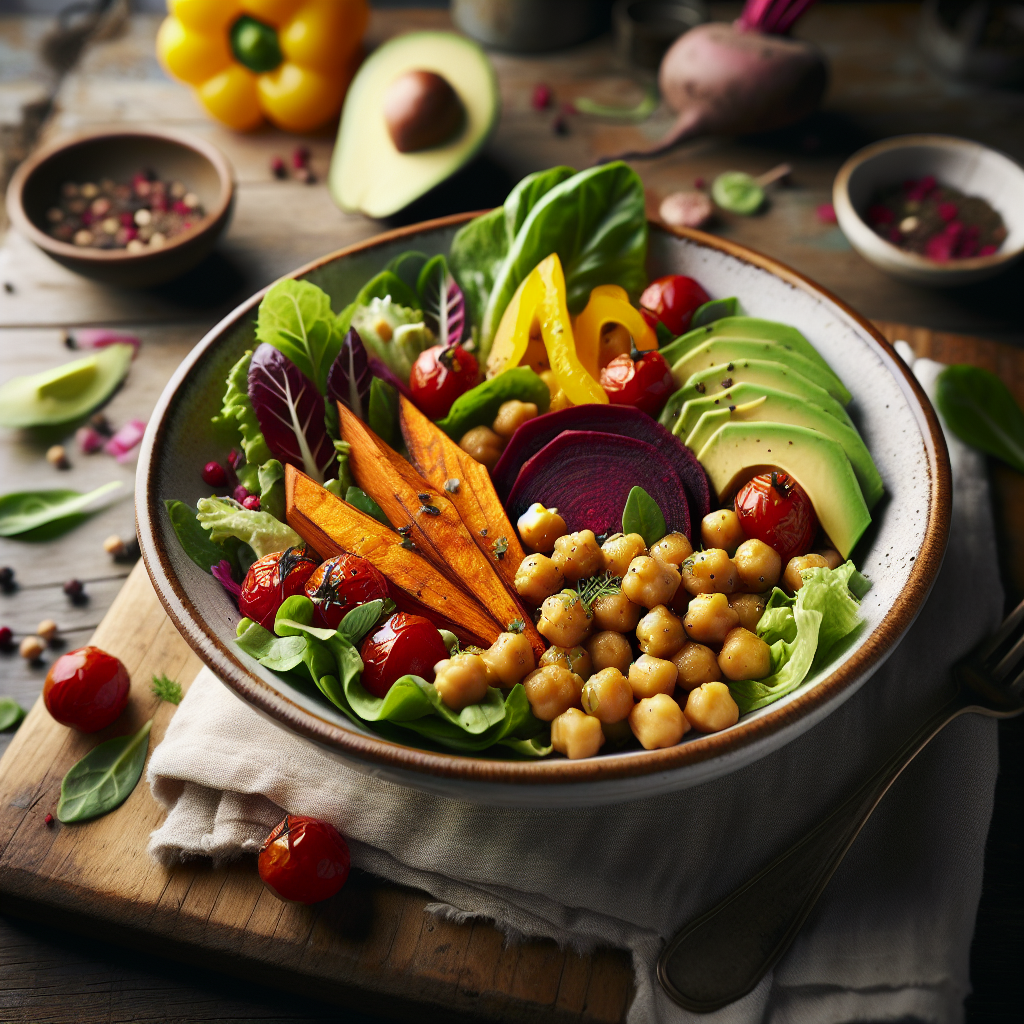

In [6]:
# Cell 4 — DALL-E 3 Food Photo Generation
def generate_food_photo(recipe_name, ingredients, cuisine):
    """Generate a professional food photo using DALL-E 3"""
    
    ingredients_str = ", ".join(ingredients[:5])
    
    prompt = (f"A stunning professional food photography shot of {recipe_name}, "
              f"featuring {ingredients_str}. {cuisine} cuisine style. "
              f"Shot on a rustic wooden table with natural lighting, "
              f"garnished beautifully, restaurant quality presentation, "
              f"shallow depth of field, highly detailed, appetizing.")
    
    print(f"Generating food photo for: {recipe_name}...")
    response = client.images.generate(
        model="dall-e-3",
        prompt=prompt,
        size="1024x1024",
        quality="standard",
        n=1
    )
    
    image_url = response.data[0].url
    
    # Download and save
    output_dir = r'C:\Users\Gurveer\ds-portfolio\project-27-recipe-maker\outputs'
    os.makedirs(output_dir, exist_ok=True)
    
    img_data = requests.get(image_url).content
    img_path = f'{output_dir}\\generated_food_photo.jpg'
    with open(img_path, 'wb') as f:
        f.write(img_data)
    
    print(f"Food photo saved to: {img_path}")
    
    # Display in notebook
    from IPython.display import display
    import IPython.display as IPdisplay
    display(IPdisplay.Image(img_path, width=500))
    
    return img_path

photo_path = generate_food_photo(
    recipe['recipe_name'],
    result['detected_items'],
    recipe['cuisine']
)

In [7]:
# Cell 5 — Export & Summary
import os

output_dir = r'C:\Users\Gurveer\ds-portfolio\project-27-recipe-maker\outputs'
os.makedirs(output_dir, exist_ok=True)

# Save recipe as JSON
with open(f'{output_dir}\\recipe.json', 'w') as f:
    json.dump(recipe, f, indent=2)

# Save detection results
detection_df = pd.DataFrame({
    'detected_items': result['detected_items'],
})
detection_df.to_csv(f'{output_dir}\\detected_ingredients.csv', index=False)

print("=== Recipe Maker Pipeline Summary ===")
print(f"\n  Vision Model:      Gemma 4 (local, 9.6GB)")
print(f"  Recipe Model:      GPT-4o-mini")
print(f"  Image Generation:  DALL-E 3")
print(f"\n  Ingredients detected: {len(result['detected_items'])}")
print(f"  Recipe created:       {recipe['recipe_name']}")
print(f"  Cuisine:              {recipe['cuisine']}")
print(f"  Prep + Cook time:     {recipe['prep_time_min'] + recipe['cook_time_min']} min")
print(f"  Calories/serving:     {recipe['nutrition_per_serving']['calories']}")
print(f"\nExports saved to outputs/")

=== Recipe Maker Pipeline Summary ===

  Vision Model:      Gemma 4 (local, 9.6GB)
  Recipe Model:      GPT-4o-mini
  Image Generation:  DALL-E 3

  Ingredients detected: 10
  Recipe created:       Mediterranean Chickpea Salad with Roasted Sweet Potato
  Cuisine:              Mediterranean
  Prep + Cook time:     35 min
  Calories/serving:     450

Exports saved to outputs/
